In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# where you wrote them earlier
SIM_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/similarity_csvs")
OUT_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/figure_creations/figures")

# dataset labels and order
GEN_ORDER = ["base_atg","base_gc","ft15_atg","ft15_gc","ft35_atg","ft35_gc"]

dfs = []
for name in GEN_ORDER:
    fp = SIM_DIR / f"{name}_similarity.csv"
    df = pd.read_csv(fp)
    df["dataset"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.head()


,Plasmid_ID,true_similarity,closest_match,closest_weighted_similarity,closest_coverage,closest_avg_identity,dataset
0,base_generated_000,0.024813,112894,0.024813,0.024813,100.000000,base_atg
1,base_generated_001,0.956202,134990,0.956033,0.956279,99.974313,base_atg
2,base_generated_002,0.390438,85613,0.390438,0.390438,100.000000,base_atg
3,base_generated_003,0.978250,108865,0.978250,0.978250,100.000000,base_atg
4,base_generated_004,0.075155,26464,0.075155,0.075155,100.000000,base_atg


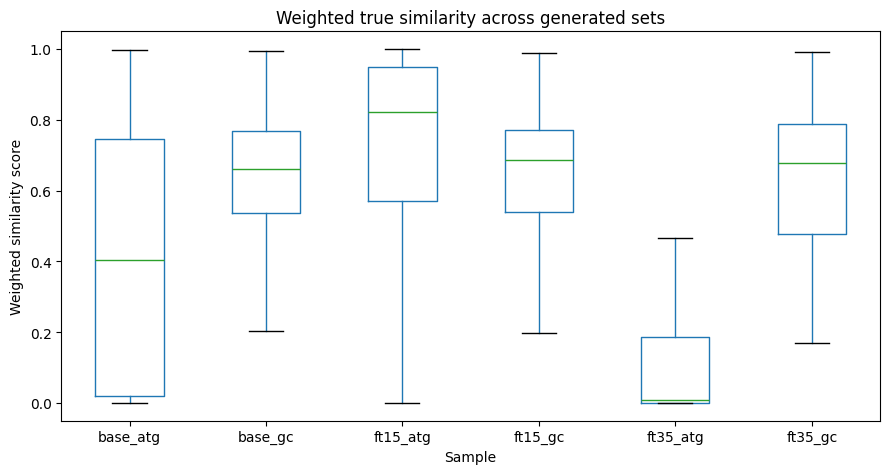

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

df_all.boxplot(
    column="true_similarity",
    by="dataset",
    ax=ax,
    grid=False,
    showfliers=False,   # optional: hide extreme outliers
)

ax.set_title("Weighted true similarity across generated sets")
ax.set_ylabel("Weighted similarity score")
ax.set_xlabel("Sample")
plt.suptitle("")  # remove default 'true_similarity by dataset'
fig.tight_layout()

fig.savefig(OUT_DIR / "boxplot_true_similarity.pdf", bbox_inches="tight")
fig.show()


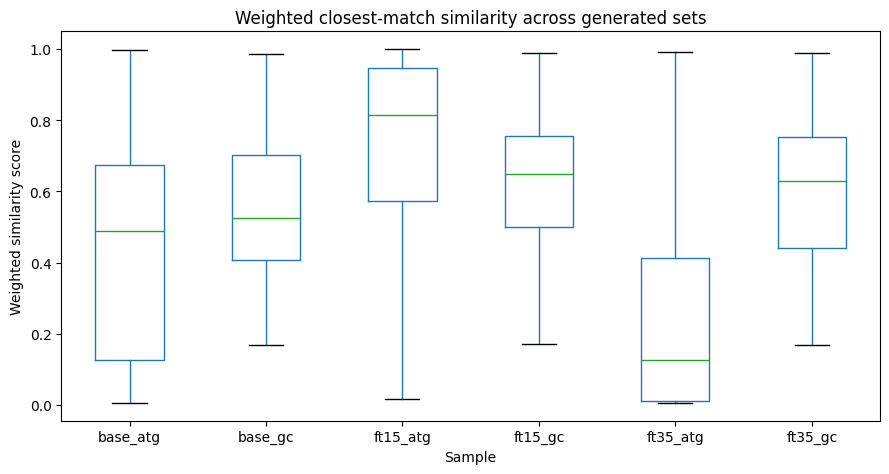

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

df_all.boxplot(
    column="closest_weighted_similarity",
    by="dataset",
    ax=ax,
    grid=False,
    showfliers=False,
)

ax.set_title("Weighted closest-match similarity across generated sets")
ax.set_ylabel("Weighted similarity score")
ax.set_xlabel("Sample")
plt.suptitle("")
fig.tight_layout()

fig.savefig(OUT_DIR / "boxplot_closest_match_similarity.pdf", bbox_inches="tight")
fig.show()
